Available datasets:
['pbmc5k_citeseq', 'brain3k_multiome', 'pbmc3k_multiome', 'pbmc10k_multiome', 'brain9k_multiome']
■ File filtered_feature_bc_matrix.h5 from pbmc5k_citeseq has been found at /root/mudatasets/pbmc5k_citeseq/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ File minipbcite.h5mu from pbmc5k_citeseq has been found at /root/mudatasets/pbmc5k_citeseq/minipbcite.h5mu
■ Checksum is validated (md5) for minipbcite.h5mu
■ File pbmc5k_citeseq_processed.h5mu from pbmc5k_citeseq has been found at /root/mudatasets/pbmc5k_citeseq/pbmc5k_citeseq_processed.h5mu


100%|██████████| 46866/46866 [00:02<00:00, 17857.25it/s, 385.4MiB, pbmc5k_citeseq_processed.h5mu, pbmc5k_citeseq]

■ Loading filtered_feature_bc_matrix.h5...
reading /root/mudatasets/pbmc5k_citeseq/filtered_feature_bc_matrix.h5


 (0:00:00)

Loaded MuData:
MuData object with n_obs × n_vars = 5247 × 33570
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	5247 × 33538
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	5247 × 32
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

Modalities: ['rna', 'prot']

Initial shapes:
RNA: (5247, 33538)
Protein: (5247, 32)

QC summary before filtering:
       total_counts  n_genes_by_counts  pct_counts_mt
count   5247.000000        5247.000000    5247.000000
mean    6141.850586        1765.344387      14.779916
std     4383.421387         970.602956      13.912645
min      501.000000          62.000000       0.000000
25%     3221.000000        1148.000000       7.230955
50%     5506.000000        1646.000000       8.985450
75%     7686.500000        2281.000000      13.338951
max    53587.000000        6959.000000      93.906685

Cells before QC: 5247
Cells p

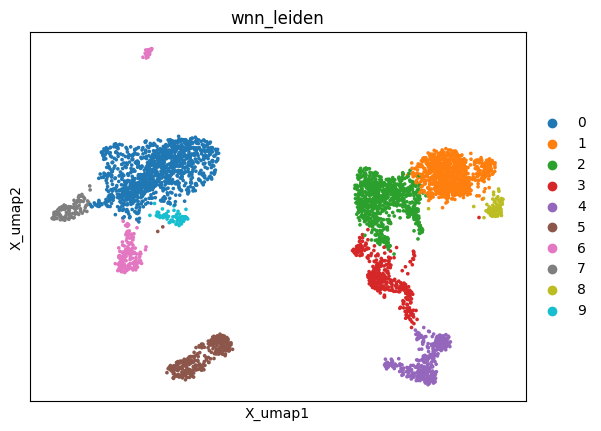

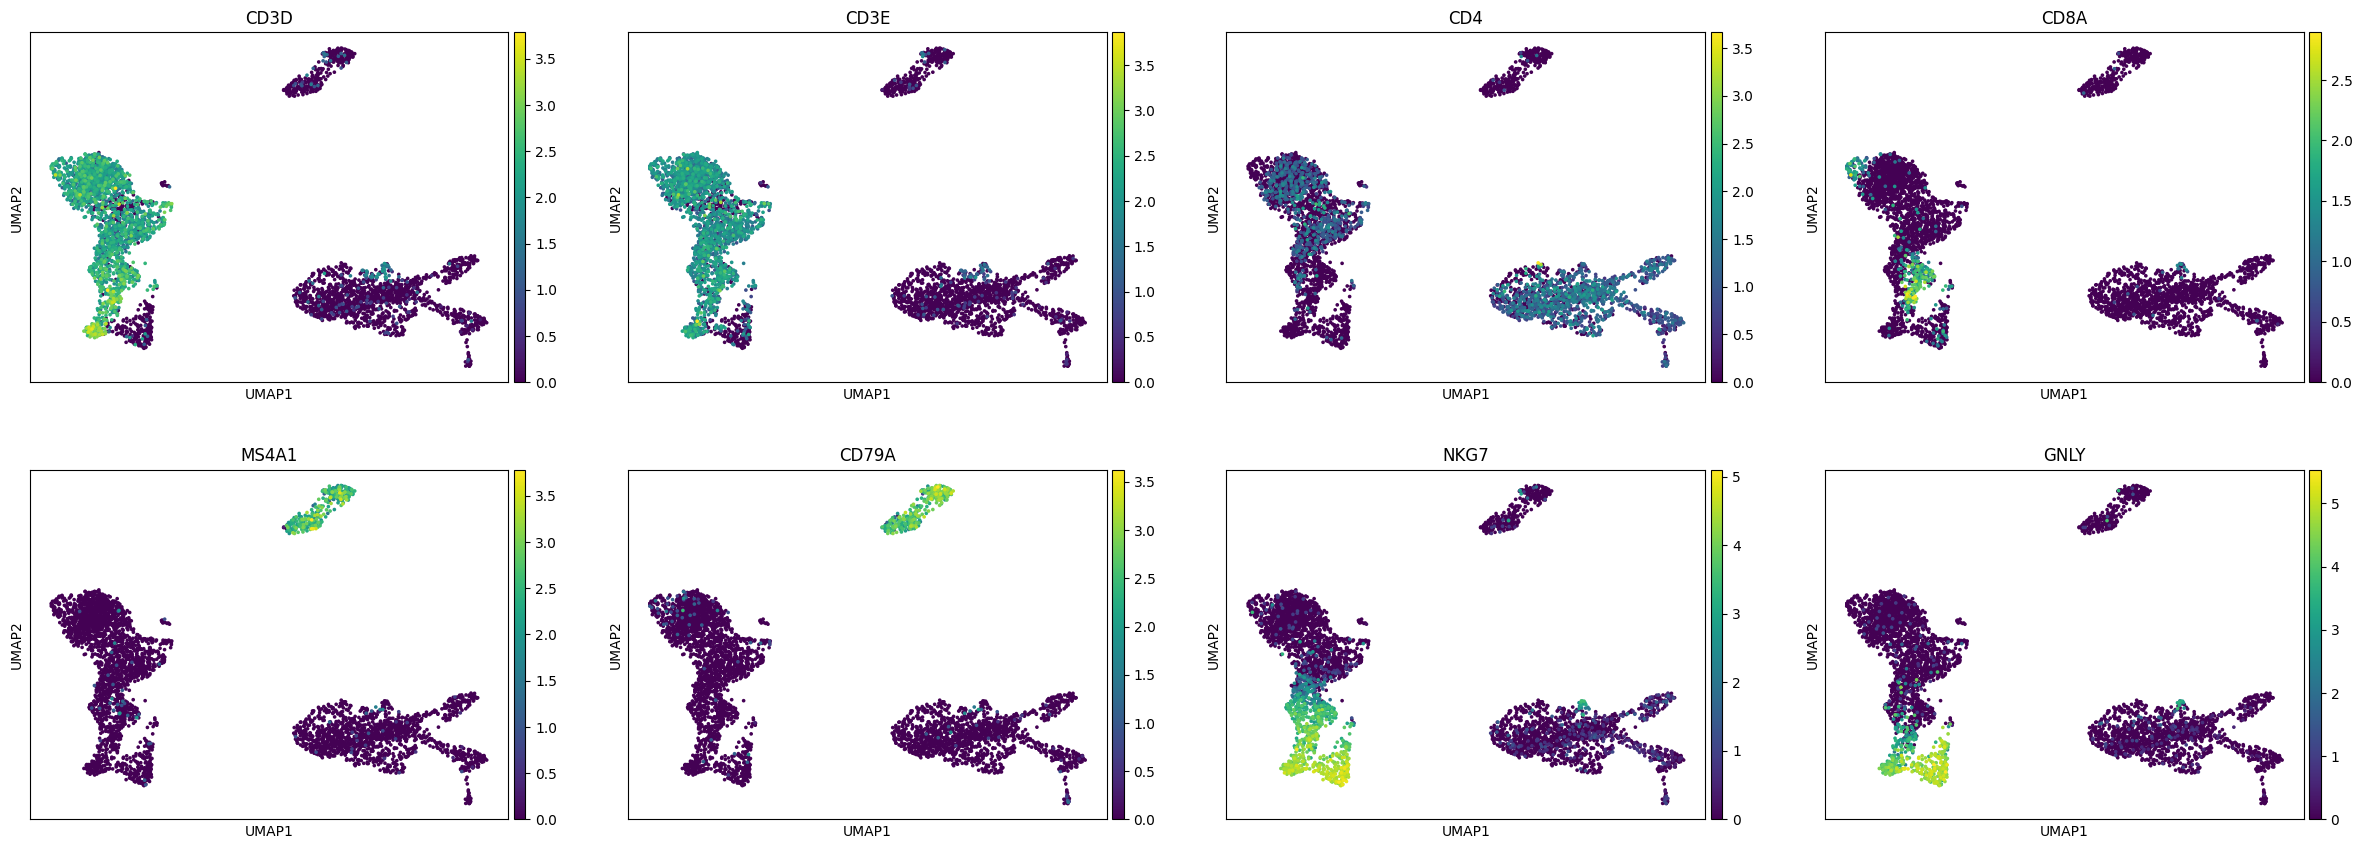


Protein / ADT markers available:
['CD3_TotalSeqB', 'CD4_TotalSeqB', 'CD8a_TotalSeqB', 'CD11b_TotalSeqB', 'CD14_TotalSeqB', 'CD15_TotalSeqB', 'CD16_TotalSeqB', 'CD19_TotalSeqB', 'CD20_TotalSeqB', 'CD25_TotalSeqB', 'CD27_TotalSeqB', 'CD28_TotalSeqB', 'CD34_TotalSeqB', 'CD45RA_TotalSeqB', 'CD45RO_TotalSeqB', 'CD56_TotalSeqB', 'CD62L_TotalSeqB', 'CD69_TotalSeqB', 'CD80_TotalSeqB', 'CD86_TotalSeqB', 'CD127_TotalSeqB', 'CD137_TotalSeqB', 'CD197_TotalSeqB', 'CD274_TotalSeqB', 'CD278_TotalSeqB', 'CD335_TotalSeqB', 'PD-1_TotalSeqB', 'HLA-DR_TotalSeqB', 'TIGIT_TotalSeqB', 'IgG1_control_TotalSeqB', 'IgG2a_control_TotalSeqB', 'IgG2b_control_TotalSeqB']
ranking genes
    finished (0:00:06)

Top marker genes:
        0      1       2      3      4         5         6       7      8  \
0  S100A9  RPL32    IL7R   CCL5   GNLY     CD79A      CD74    LST1   CD8B   
1  S100A8  RPL30    IL32   NKG7   NKG7     MS4A1  HLA-DPA1  FCGR3A  RPS3A   
2     LYZ  RPS3A    TRAC   CST7   PRF1     CD79B  HLA-DPB1    A

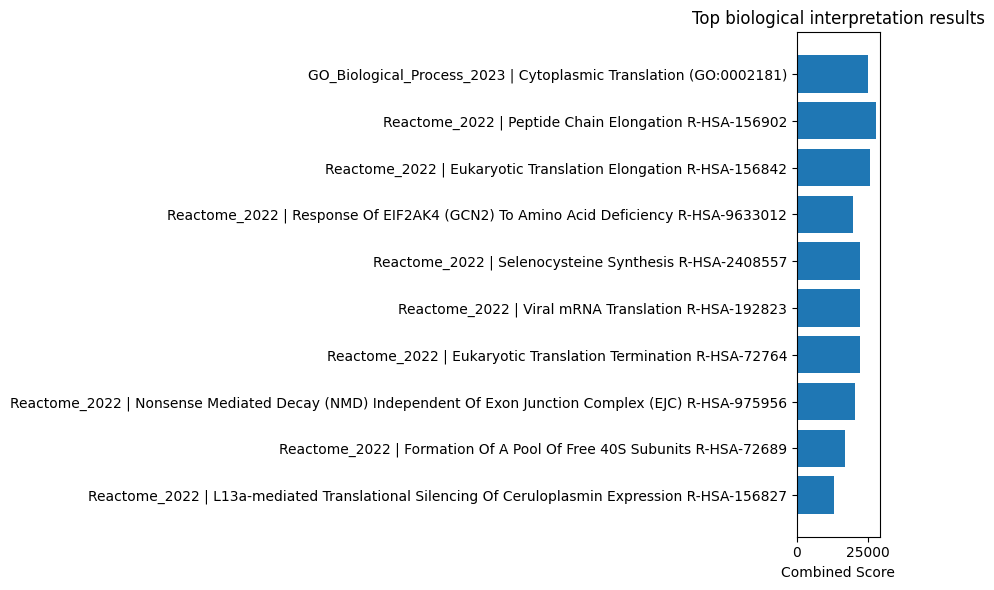


DONE ✅
Saved:
- multimodal_marker_genes.csv
- multimodal_pathway_results.csv
- pbmc5k_citeseq_processed_pipeline.h5mu


In [9]:
# ============================================================
# FULL ROBUST CITE-seq MULTI-OMICS PIPELINE
# Dataset: pbmc5k_citeseq
# Loader: mudatasets
# Container: MuData / Muon
# Analysis: Scanpy + Muon
# Interpretation: GSEApy / Enrichr
# ============================================================

# ============================================================
# 0. INSTALL DEPENDENCIES
# ============================================================
# In Colab/Jupyter, run this cell first.
# If leidenalg was missing, restart runtime/kernel after install.

!pip install -q muon mudatasets scanpy gseapy leidenalg python-igraph

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import mudatasets as mds
import gseapy as gp
import matplotlib.pyplot as plt

sc.settings.verbosity = 2

# ============================================================
# 2. LOAD MULTI-OMICS DATA AUTOMATICALLY
# ============================================================

print("Available datasets:")
print(mds.list_datasets())

# mudatasets.load returns ONE MuData object here
mdata = mds.load("pbmc5k_citeseq", full=True)

# Make feature names unique in each modality
for mod in mdata.mod:
    mdata.mod[mod].var_names_make_unique()

mdata.update()

print("\nLoaded MuData:")
print(mdata)
print("\nModalities:", list(mdata.mod.keys()))

rna_key = "rna"
prot_key = "prot"

rna = mdata.mod[rna_key]
prot = mdata.mod[prot_key]

print("\nInitial shapes:")
print("RNA:", rna.shape)
print("Protein:", prot.shape)

# ============================================================
# 3. QC SAFELY WITHOUT BREAKING MUDATA
# ============================================================

# Mitochondrial genes
rna.var["mt"] = rna.var_names.str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    rna,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

print("\nQC summary before filtering:")
print(
    rna.obs[
        ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
    ].describe()
)

# Cell-level QC mask
cell_mask = (
    (rna.obs["n_genes_by_counts"] >= 200) &
    (rna.obs["pct_counts_mt"] <= 25)
)

print("\nCells before QC:", mdata.n_obs)
print("Cells passing QC:", int(cell_mask.sum()))

# Subset WHOLE MuData object once
mdata = mdata[cell_mask.values, :].copy()
mdata.update()

rna = mdata.mod[rna_key]
prot = mdata.mod[prot_key]

# Gene-level filtering only on RNA modality
sc.pp.filter_genes(rna, min_cells=3)

mdata.update()

rna = mdata.mod[rna_key]
prot = mdata.mod[prot_key]

print("\nAfter QC:")
print(mdata)
print("RNA:", rna.shape)
print("Protein:", prot.shape)

# ============================================================
# 4. RNA PROCESSING
# ============================================================

rna.layers["counts"] = rna.X.copy()

sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

# Store normalized log data as raw for plotting/marker tests
rna.raw = rna.copy()

sc.pp.highly_variable_genes(
    rna,
    n_top_genes=2000,
    flavor="seurat"
)

sc.pp.scale(rna, max_value=10)

sc.tl.pca(rna, n_comps=30)

# IMPORTANT:
# Since key_added="rna_neighbors" is used,
# downstream UMAP/Leiden must use neighbors_key="rna_neighbors".
sc.pp.neighbors(
    rna,
    n_neighbors=15,
    n_pcs=30,
    key_added="rna_neighbors"
)

sc.tl.umap(
    rna,
    neighbors_key="rna_neighbors"
)

sc.tl.leiden(
    rna,
    resolution=0.5,
    neighbors_key="rna_neighbors",
    key_added="rna_leiden"
)

print("\nRNA analysis complete.")

# ============================================================
# 5. PROTEIN / ADT PROCESSING
# ============================================================

prot.layers["counts"] = prot.X.copy()

# Tutorial-level ADT normalization.
# For deeper CITE-seq, DSB normalization is better when raw/background/isotype controls exist.
sc.pp.normalize_total(prot, target_sum=1e4)
sc.pp.log1p(prot)

sc.pp.scale(prot, max_value=10)

n_prot_comps = min(20, prot.n_vars - 1)

sc.tl.pca(prot, n_comps=n_prot_comps)

sc.pp.neighbors(
    prot,
    n_neighbors=15,
    n_pcs=n_prot_comps,
    key_added="prot_neighbors"
)

sc.tl.umap(
    prot,
    neighbors_key="prot_neighbors"
)

sc.tl.leiden(
    prot,
    resolution=0.5,
    neighbors_key="prot_neighbors",
    key_added="prot_leiden"
)

print("Protein / ADT analysis complete.")

# Synchronize parent MuData
mdata.update()

# ============================================================
# 6. MULTIMODAL INTEGRATION
# ============================================================

try:
    mu.pp.neighbors(
        mdata,
        key_added="wnn",
        neighbor_keys={
            rna_key: "rna_neighbors",
            prot_key: "prot_neighbors",
        }
    )

    mu.tl.umap(
        mdata,
        neighbors_key="wnn"
    )

    sc.tl.leiden(
        mdata,
        neighbors_key="wnn",
        resolution=0.5,
        key_added="wnn_leiden"
    )

    cluster_key = "wnn_leiden"
    print("\nMultimodal WNN-style integration complete.")

except Exception as e:
    print("\nMultimodal integration failed in this installed version.")
    print("Reason:", repr(e))
    print("Using RNA clusters as fallback.")

    mdata.obs["rna_leiden"] = rna.obs["rna_leiden"].astype(str).values
    cluster_key = "rna_leiden"

# ============================================================
# 7. VISUALIZE CLUSTERS AND BASIC MARKERS
# ============================================================

print("\nCluster key used:", cluster_key)

if "X_umap" in mdata.obsm:
    mu.pl.umap(mdata, color=[cluster_key])
else:
    sc.pl.umap(rna, color=["rna_leiden"])

candidate_genes = [
    "CD3D", "CD3E", "CD4", "CD8A",
    "MS4A1", "CD79A",
    "NKG7", "GNLY",
    "LYZ", "FCGR3A", "PPBP"
]

present_genes = [g for g in candidate_genes if g in rna.var_names]

if len(present_genes) > 0:
    sc.pl.umap(
        rna,
        color=present_genes[:8],
        use_raw=True
    )

print("\nProtein / ADT markers available:")
print(list(prot.var_names))

# ============================================================
# 8. MARKER GENE DISCOVERY
# ============================================================

# Put final cluster labels into RNA obs for marker testing
if cluster_key in mdata.obs.columns:
    rna.obs[cluster_key] = (
        mdata.obs.loc[rna.obs_names, cluster_key]
        .astype(str)
        .values
    )
else:
    cluster_key = "rna_leiden"

sc.tl.rank_genes_groups(
    rna,
    groupby=cluster_key,
    method="wilcoxon",
    use_raw=True
)

marker_df = pd.DataFrame(
    rna.uns["rank_genes_groups"]["names"]
)

print("\nTop marker genes:")
print(marker_df.head(10))

# Clean marker list for enrichment
gene_list = (
    marker_df
    .head(50)
    .values
    .flatten()
    .tolist()
)

gene_list = [g for g in gene_list if isinstance(g, str)]
gene_list = list(dict.fromkeys(gene_list))

print("\nNumber of marker genes for pathway analysis:", len(gene_list))
print(gene_list[:30])

# ============================================================
# 9. PATHWAY / BIOLOGICAL INTERPRETATION
# ============================================================

pathway_results = None

if len(gene_list) >= 5:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[
            "KEGG_2021_Human",
            "GO_Biological_Process_2023",
            "Reactome_2022"
        ],
        organism="human",
        outdir=None
    )

    pathway_results = enr.results.sort_values(
        "Adjusted P-value"
    )

    print("\nTop pathway results:")
    print(
        pathway_results[
            [
                "Gene_set",
                "Term",
                "Adjusted P-value",
                "Combined Score",
                "Overlap"
            ]
        ].head(20)
    )

    top_plot = pathway_results.head(10).copy()
    top_plot["label"] = (
        top_plot["Gene_set"] + " | " + top_plot["Term"]
    )

    plt.figure(figsize=(9, 6))
    plt.barh(
        top_plot["label"],
        top_plot["Combined Score"]
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Combined Score")
    plt.title("Top biological interpretation results")
    plt.tight_layout()
    plt.show()

else:
    print("Not enough marker genes for pathway enrichment.")

# ============================================================
# 10. SAVE OUTPUTS
# ============================================================

marker_df.to_csv("multimodal_marker_genes.csv", index=False)

if pathway_results is not None:
    pathway_results.to_csv(
        "multimodal_pathway_results.csv",
        index=False
    )

mdata.write("pbmc5k_citeseq_processed_pipeline.h5mu")

print("\nDONE ✅")
print("Saved:")
print("- multimodal_marker_genes.csv")
print("- multimodal_pathway_results.csv")
print("- pbmc5k_citeseq_processed_pipeline.h5mu")